In [1]:
# ==========================================================
# Notebook 06: EV and PV synergy
#
# Goal:
# Compare EV charging demand with PV production.
#
# Main question:
# Does uncontrolled ASAP charging naturally align with PV
# production, or is optimization needed?
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [2]:
# ==========================================================
# Load EV and yearly OSOPSS datasets
# ==========================================================

ev = pd.read_csv("../data/raw/ev_sessions.csv")

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()

In [3]:
# ==========================================================
# Select representative high-demand day
# ==========================================================

DAY = 95
S_PV = 300  # PV size [kWp]

ev_day = ev[ev["day"] == DAY].copy()

building_day = load_year[(DAY - 1) * 24 : DAY * 24]
pv_day = S_PV * pv_factor[(DAY - 1) * 24 : DAY * 24]

print("Day:", DAY)
print("EV sessions:", len(ev_day))
print("EV energy [kWh]:", ev_day["energy_kwh"].sum())
print("Building energy [kWh]:", building_day.sum())
print("PV energy [kWh]:", pv_day.sum())

Day: 95
EV sessions: 35
EV energy [kWh]: 509.0
Building energy [kWh]: 1432.217753386
PV energy [kWh]: 1674.636


In [4]:
# ==========================================================
# Build ASAP EV charging profile
# ==========================================================

charger_power = 7.0
hours = np.arange(24)
ev_asap = np.zeros(24)

for _, car in ev_day.iterrows():

    energy_remaining = car["energy_kwh"]

    if energy_remaining <= 0:
        continue

    start_min = int(car["connection_minute"])
    end_min = int(car["full_minute"])

    for h in range(24):

        hour_start = h * 60
        hour_end = (h + 1) * 60

        overlap_min = max(
            0,
            min(end_min, hour_end) - max(start_min, hour_start)
        )

        if overlap_min > 0:
            energy_this_hour = charger_power * overlap_min / 60
            energy_this_hour = min(energy_this_hour, energy_remaining)

            ev_asap[h] += energy_this_hour
            energy_remaining -= energy_this_hour

print("ASAP EV energy [kWh]:", ev_asap.sum())

ASAP EV energy [kWh]: 509.0


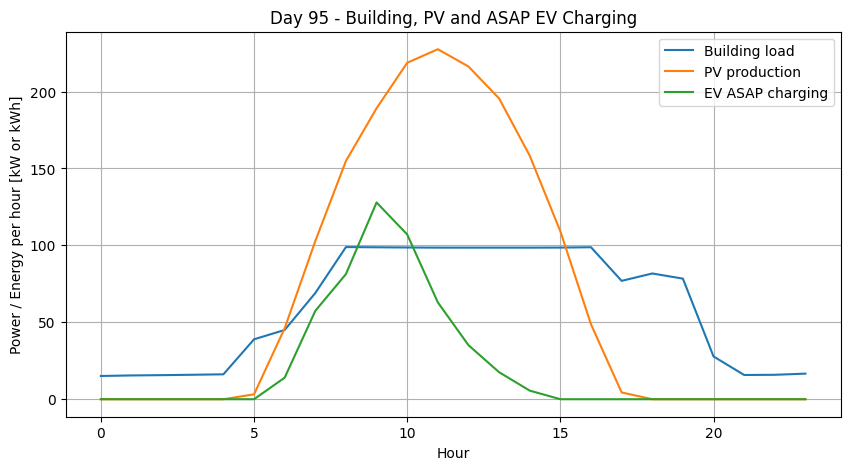

In [5]:
# ==========================================================
# Compare building load, PV production and ASAP EV charging
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(hours, building_day, label="Building load")
plt.plot(hours, pv_day, label="PV production")
plt.plot(hours, ev_asap, label="EV ASAP charging")

plt.xlabel("Hour")
plt.ylabel("Power / Energy per hour [kW or kWh]")
plt.title("Day 95 - Building, PV and ASAP EV Charging")
plt.grid()
plt.legend()

plt.show()

There is still unused PV 10:00 to 15:00 ~ Thus we can optimise it ..... use noon PV surplus

In [6]:
# ==========================================================
# Correct direct PV usage by ASAP EV charging
#
# Important correction:
# PV is first used to cover the building load.
# Only the remaining PV surplus can be used for EV charging.
#
# Therefore:
# PV available for EVs = max(PV production - building load, 0)
# ==========================================================

pv_surplus_after_building = np.maximum(
    pv_day - building_day,
    0
)

pv_to_ev = np.minimum(
    pv_surplus_after_building,
    ev_asap
)

grid_to_ev = ev_asap - pv_to_ev

print("EV charging energy [kWh]:", ev_asap.sum())
print("PV surplus available for EVs [kWh]:",
      pv_surplus_after_building.sum())
print("PV directly used by EVs [kWh]:",
      pv_to_ev.sum())
print("Grid energy used by EVs [kWh]:",
      grid_to_ev.sum())

print(
    "Fraction of EV charging supplied by PV [%]:",
    100 * pv_to_ev.sum() / ev_asap.sum()
)

EV charging energy [kWh]: 509.0
PV surplus available for EVs [kWh]: 715.31213371635
PV directly used by EVs [kWh]: 409.5339138990167
Grid energy used by EVs [kWh]: 99.46608610098332
Fraction of EV charging supplied by PV [%]: 80.45852925324493


Loop over the three scenarios

In [7]:
scenario_days = {
    "low": 106,
    "medium": 20,
    "high": 95,
}

In [8]:
# ==========================================================
# Function to build ASAP EV charging profile for one day
# ==========================================================

def build_asap_ev_profile(ev_day, charger_power=7.0):
    """
    Build hourly ASAP charging profile.

    ASAP means:
    - EV starts charging immediately at connection time.
    - EV charges until its required energy is delivered.
    - Charging power is fixed.
    """

    ev_asap = np.zeros(24)

    for _, car in ev_day.iterrows():

        energy_remaining = car["energy_kwh"]

        if energy_remaining <= 0:
            continue

        start_min = int(car["connection_minute"])
        end_min = int(car["full_minute"])

        for h in range(24):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(end_min, hour_end) - max(start_min, hour_start)
            )

            if overlap_min > 0:

                energy_this_hour = charger_power * overlap_min / 60

                energy_this_hour = min(
                    energy_this_hour,
                    energy_remaining
                )

                ev_asap[h] += energy_this_hour

                energy_remaining -= energy_this_hour

    return ev_asap

In [9]:
# ==========================================================
# Evaluate EV-PV interaction for all representative days
# ==========================================================

S_PV = 300  # fixed PV size [kWp]

scenario_results = []

for scenario_name, day in scenario_days.items():

    ev_day = ev[ev["day"] == day].copy()

    building_day = load_year[(day - 1) * 24 : day * 24]

    pv_day = S_PV * pv_factor[(day - 1) * 24 : day * 24]

    ev_asap = build_asap_ev_profile(ev_day)

    pv_surplus_after_building = np.maximum(
        pv_day - building_day,
        0
    )

    pv_to_ev = np.minimum(
        pv_surplus_after_building,
        ev_asap
    )

    grid_to_ev = ev_asap - pv_to_ev

    scenario_results.append({
        "scenario": scenario_name,
        "day": day,
        "EV energy [kWh]": ev_asap.sum(),
        "PV surplus after building [kWh]": pv_surplus_after_building.sum(),
        "PV used by EV [kWh]": pv_to_ev.sum(),
        "Grid used by EV [kWh]": grid_to_ev.sum(),
        "EV supplied by PV [%]": 100 * pv_to_ev.sum() / ev_asap.sum()
    })

scenario_results_df = pd.DataFrame(scenario_results)

scenario_results_df

,scenario,day,EV energy [kWh],PV surplus after building [kWh],PV used by EV [kWh],Grid used by EV [kWh],EV supplied by PV [%]
0,low,106,37.000000,604.786387,37.000000,0.000000,100.000000
1,medium,20,297.833333,0.000000,0.000000,297.833333,0.000000
2,high,95,509.000000,715.312134,409.533914,99.466086,80.458529


The benefit of smart charging depends strongly on the daily pattern.